# t2i v6.0 · 判分结果审阅（三消融 → case 逐项）

数据：`eval_score.py score --v60 {V2,V5} --model <判官> --source <图源>` 产出的 `scores_t2i_v60_*.jsonl`。
当前覆盖：gpt-5.6-sol（V2/V5 全 40）、claude-opus-5（V2 双图源 20）、gemini-2.5-pro（V2 partial，已取消）。

- **Cell 1** 数据加载与总览：三消融汇总表 + 覆盖面
- **Cell 2** 消融① 判官（V2 两两）：一致率热力图 / 逐项均档散点（中文）/ 最大分歧 case（图+证据）
- **Cell 3** 消融② 条件 V2 vs V5（仅 gpt-5.6-sol 有配对）：线级差分 / 逐项对比与迁移 / 翻转证据下钻
- **Cell 4** 消融③ 图源 bagel vs gpt-image-2：三线 / 22 项明细 / 零档频次 / 难度剖面 / 热力表
- **Cell 5** case 逐项对比：题面+图+全组合打分矩阵、V2/V5 哑铃卡、reasons 查阅

In [42]:
# ---- v6.0 判分结果 · 数据加载与三消融总览 ----
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# cwd 自适应：仓库根或 benchmark/t2i/ 启动均可
EVAL_DIR = (Path.cwd() / 'data' if (Path.cwd() / 'data' / 'samples_v60_uniform.jsonl').exists()
            else Path.cwd() / 'benchmark' / 't2i' / 'data')
assert EVAL_DIR.exists(), f'请从仓库根或 benchmark/t2i/ 启动 kernel（当前 {Path.cwd()}）'
PHI = {0: 0.0, 1: 60.0, 2: 100.0}   # 0→0 / 1→60 / 2→100，N/A 剔除
COND_JUDGE = 'openrouter/openai/gpt-5.6-sol'   # V2/V5 消融只用该判官（唯一有 V5 配对）
plt.rcParams['font.family'] = ['Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

ITEM_ZH = {'subject_presence': '主体在场', 'form_structure': '形态结构',
           'color_material': '颜色材质', 'quantity_scale': '数量尺度',
           'spatial_relation': '空间关系', 'text_symbol': '文字符号',
           'action_interaction': '动作交互', 'state_context': '状态情境',
           'scene_environment': '场景环境', 'style': '风格',
           'physical_logic': '物理逻辑', 'material_texture': '材质质感',
           'detail_richness': '细节丰富', 'artifacts': '伪影', 'resolution': '分辨率',
           'edge_clarity': '边缘清晰', 'naturalness': '自然度',
           'anatomical_fidelity': '解剖保真', 'composition': '构图',
           'color_harmony': '色彩和谐', 'lighting_atmosphere': '光影氛围',
           'emotional_expression': '情绪传达'}
DIM_ZH = {'alignment': '对齐', 'quality': '质量', 'aesthetics': '美感'}
def _zh(t):
    """(dim, item) 多级索引 → (中文维度, 中文项名)"""
    return (DIM_ZH.get(t[0], t[0]), ITEM_ZH.get(t[1], t[1]))
RK = {'alignment': ('alignment_scores', 'alignment_reasons'),
      'quality': ('quality_scores', 'quality_reasons'),
      'aesthetics': ('aesthetic_scores', 'aesthetic_reasons')}
IMG_OF = {'gpt-image-2': lambda q: EVAL_DIR / 'eval_v60_r6' / 'imgs' / 'gpt-image-2' / f'{q}.png',
          'bagel': lambda q: EVAL_DIR / 'eval_v60_r6' / 'bagel' / 'imgs' / f'{q}.png'}
QS = {q['qid']: q for q in
      (json.loads(l) for l in
       (EVAL_DIR / 'synth_gen_v60_r6' / 'questions_v60_gpt-5.6-sol.jsonl')
       .read_text(encoding='utf-8').splitlines() if l.strip())}

rows, fails = [], []
for fp in sorted(EVAL_DIR.glob('scores_t2i_v60_*.jsonl')):
    for line in fp.read_text(encoding='utf-8').splitlines():
        if line.strip():
            (fails if json.loads(line).get('fail') else rows).append(json.loads(line))
df = pd.DataFrame(rows)
assert rows, f'尚无 {EVAL_DIR}/scores_t2i_v60_*.jsonl'
print(f'判分 {len(rows)} 行（fail {len(fails)} 行已剔除）；覆盖组合（判官 × 条件 × 图源）：')
print(df.groupby(['judge_model', 'schema', 'image_model']).size().rename('n').to_string())

print('\n① 三消融总览：判官 × 条件 × 图源 → 三线分均值')
display(df.groupby(['judge_model', 'schema', 'image_model'])
          .agg(n=('qid', 'size'), align=('alignment_score', 'mean'),
               quality=('quality_score', 'mean'), aesthetic=('aesthetic_score', 'mean'))
          .round(1))

判分 72 行（fail 4 行已剔除）；覆盖组合（判官 × 条件 × 图源）：
judge_model                         schema   image_model
openrouter/anthropic/claude-opus-5  v6.0-V2  bagel          10
                                             gpt-image-2    10
openrouter/google/gemini-2.5-pro    v6.0-V2  bagel           4
                                             gpt-image-2     8
openrouter/openai/gpt-5.6-sol       v6.0-V2  bagel          10
                                             gpt-image-2    10
                                    v6.0-V5  bagel          10
                                             gpt-image-2    10

① 三消融总览：判官 × 条件 × 图源 → 三线分均值


n  align  quality  \
judge_model                        schema  image_model                       
openrouter/anthropic/claude-opus-5 v6.0-V2 bagel        10   35.0     53.0   
                                           gpt-image-2  10   60.1     61.6   
openrouter/google/gemini-2.5-pro   v6.0-V2 bagel         4   46.8     58.1   
                                           gpt-image-2   8   74.4     67.7   
openrouter/openai/gpt-5.6-sol      v6.0-V2 bagel        10   27.7     43.3   
                                           gpt-image-2  10   71.1     70.9   
                                   v6.0-V5 bagel        10   27.3     46.1   
                                           gpt-image-2  10   70.0     71.9   

                                                        aesthetic  
judge_model                        schema  image_model             
openrouter/anthropic/claude-opus-5 v6.0-V2 bagel             60.0  
                                           gpt-image-2       60.0  
openrouter/google/gemini-2.5-pro   v6.0-V2 bagel             70.8  
                                           gpt-image-2       76.7  
openrouter/openai/gpt-5.6-sol      v6.0-V2 bagel             61.0  
                                           gpt-image-2       71.3  
                                   v6.0-V5 bagel             60.0  
                                           gpt-image-2       78.7

各判官 V2 三线均分（全局印象：谁整体更严/更松）：


,对齐,质量,美感
judge_model,,,
openrouter/anthropic/claude-opus-5,47.6,57.3,60.0
openrouter/google/gemini-2.5-pro,65.2,64.5,74.7
openrouter/openai/gpt-5.6-sol,49.4,57.1,66.2


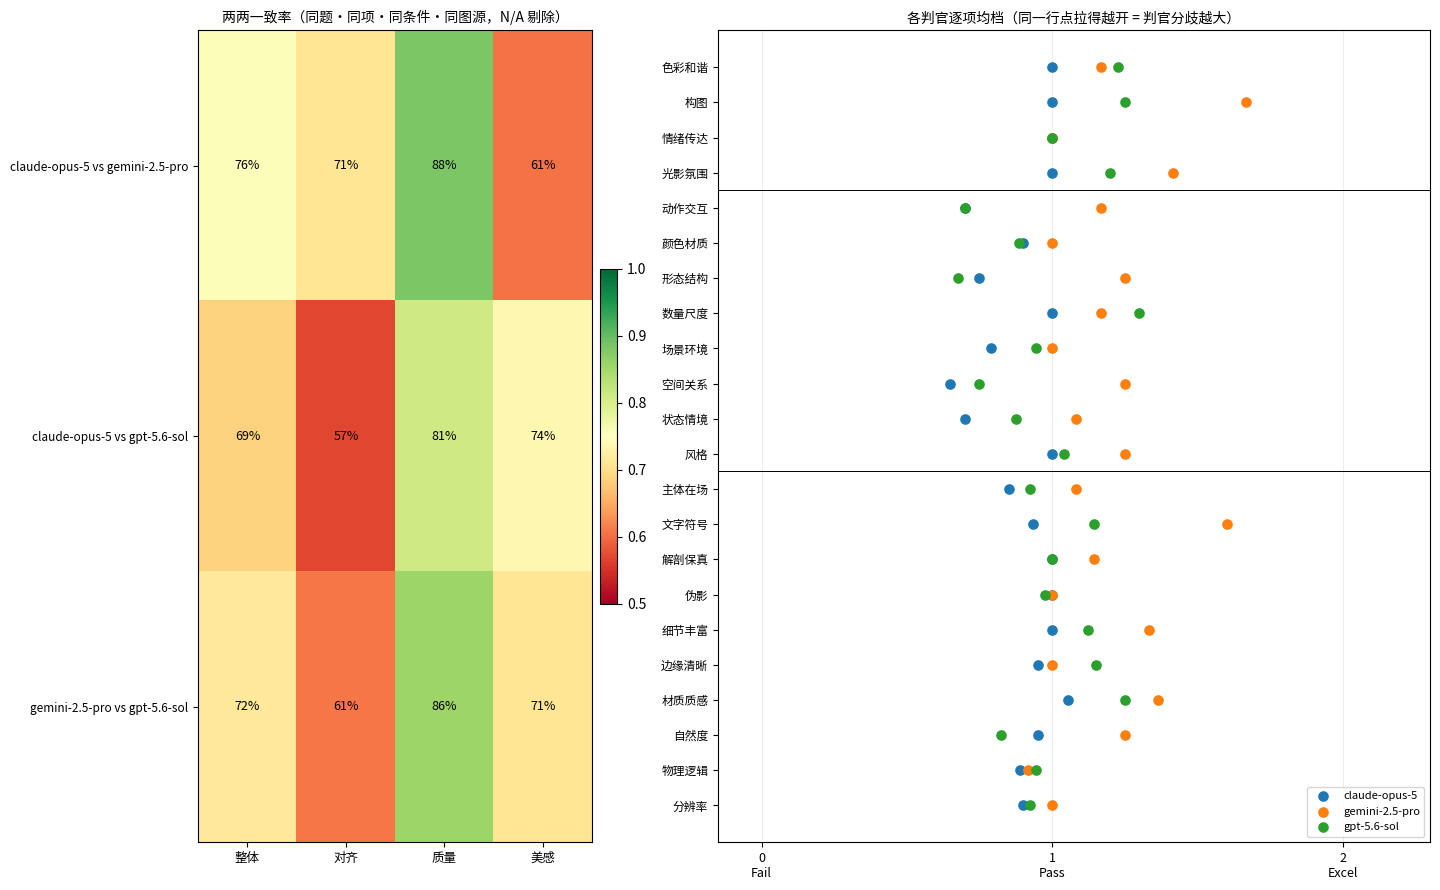


最大分歧 TOP6（同题同项判官档位极差 ≥1；附图 + 各方档位与证据）：
--- [60003·V2·gpt-image-2] 空间关系（极差 2 档）
       claude-opus-5: 1  | 卡车平行停在挖掘机履带右侧，低机位正侧方取景，前景静水中同时呈现挖掘机、卡车的完整倒影，倒影中车牌与 SUNWARD 字样均为左
      gemini-2.5-pro: 2  | 画面精确执行了复杂的空间布局指令：卡车平行于挖掘机履带停放，前景有积水，采用低机位侧方视角，且将车辆、卸料动作和完整的倒影全部纳
         gpt-5.6-sol: 0  | 卡车确实平行位于挖掘机履带一侧，但挖掘机动臂和铲斗的倒影延伸至画面下边缘并被明显裁断，未呈现题面要求的完整倒影。
--- [60007·V2·gpt-image-2] 状态情境（极差 2 档）
       claude-opus-5: 1  | 左株菌盖闭合紧贴菌柄、菌褶洁白，为适食幼嫩期；右株盖缘变黑上卷、菌褶墨化并出墨滴，为刚进入的早期自溶期。
      gemini-2.5-pro: 2  | 画面通过颜色、形态和自溶液滴，清晰对比呈现了鸡腿菇“幼嫩未开伞期”与“早期自溶期”两个阶段，状态符合题面设定。
         gpt-5.6-sol: 0  | 右株菌盖下半部已大面积黑化液化，外表分布多颗黑色流滴且菌褶有连续滴流，呈现程度明显超过“刚进入早期自溶、第一滴刚离开”的初始状态
--- [60007·V2·gpt-image-2] 形态结构（极差 2 档）
       claude-opus-5: 1  | 两株各有一半以剖面朝向镜头，可见菌盖纵切轮廓、放射状菌褶与菌柄纵剖髓心；另一半呈鳞片外表面，形态为毛头鬼伞特有的长圆柱状菌盖。
      gemini-2.5-pro: 2  | 两株菌物均按题面要求沿中轴纵向剖开，精确展示了剖面与外表面，此为对复杂结构指令的卓越执行。
         gpt-5.6-sol: 0  | 四个半体下方均呈近似完整圆柱状菌柄，朝镜头的剖开半体没有清楚显示沿菌柄中轴纵剖后的连续平面剖面，违反两株均纵向剖半的结构要求。
--- [60005·V2·gpt-image-2] 空间关系（极差 2 档）
       claude-opus-5: 

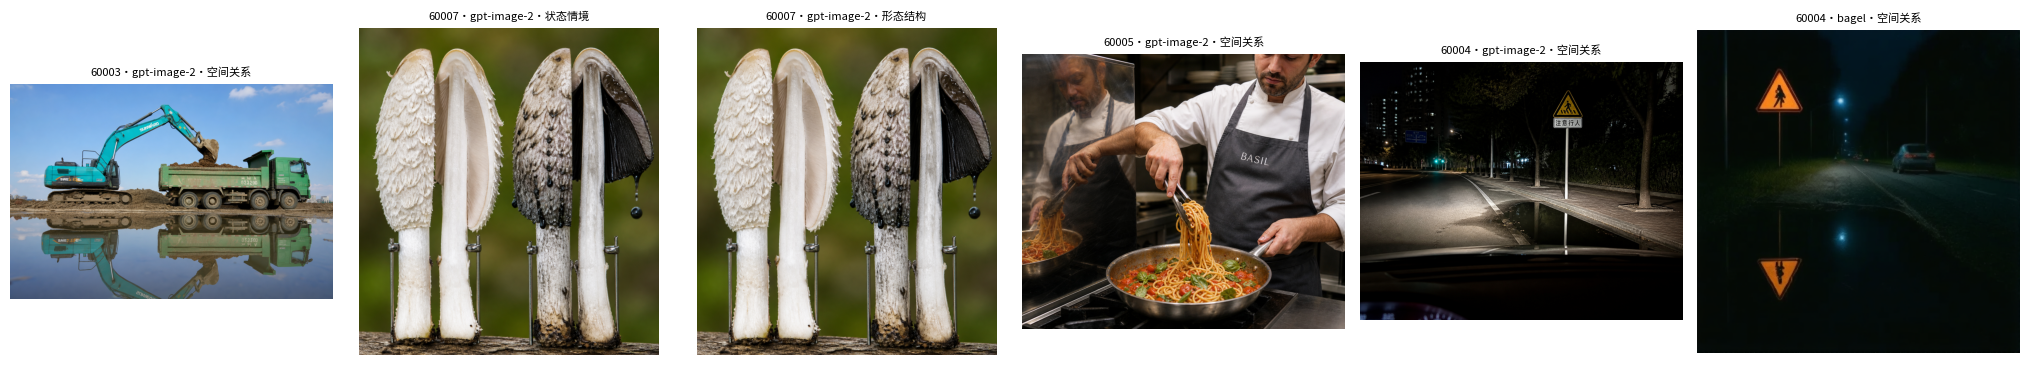

In [43]:
# ---- 消融① 判官（V2 口径两两比较；V5 仅 gpt-5.6-sol 有，不进本节）----
import numpy as np
from PIL import Image
from itertools import combinations

items = pd.DataFrame([
    {'qid': r['qid'], 'schema': r['schema'], 'image_model': r['image_model'],
     'judge': r['judge_model'], 'dim': d, 'item': k, 'score': v}
    for r in rows
    for d, (sk, _) in RK.items()
    for k, v in r[sk].items() if v in (0, 1, 2)])
piv = items.pivot_table(index=['qid', 'schema', 'image_model', 'dim', 'item'],
                        columns='judge', values='score').dropna()
JS = sorted(piv.columns)

if len(JS) >= 2:
    print('各判官 V2 三线均分（全局印象：谁整体更严/更松）：')
    display(df[df['schema'] == 'v6.0-V2']
            .groupby('judge_model')[['alignment_score', 'quality_score', 'aesthetic_score']]
            .mean().round(1).rename(columns={'alignment_score': '对齐', 'quality_score': '质量',
                                             'aesthetic_score': '美感'}))
    ag_rows = []
    for ja, jb in combinations(JS, 2):
        sub = piv[[ja, jb]].dropna()
        if not len(sub):
            continue
        same = sub[ja] == sub[jb]
        per_dim = same.groupby(sub.index.get_level_values('dim')).mean()
        ag_rows.append({'配对': f"{ja.split('/')[-1]} vs {jb.split('/')[-1]}",
                        '整体': float(same.mean()),
                        **{d: float(per_dim[d]) if d in per_dim.index else float('nan')
                           for d in ('alignment', 'quality', 'aesthetics')}})
    ag = pd.DataFrame(ag_rows).set_index('配对')
    jm = items.pivot_table(index=['dim', 'item'], columns='judge', values='score',
                           aggfunc='mean')[JS]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 9),
                                   gridspec_kw={'width_ratios': [1, 1.7]})
    im_ = ax1.imshow(ag.values, vmin=0.5, vmax=1.0, cmap='RdYlGn', aspect='auto')
    ax1.set_xticks(range(ag.shape[1]))
    ax1.set_xticklabels(['整体', '对齐', '质量', '美感'], fontsize=9)
    ax1.set_yticks(range(ag.shape[0]))
    ax1.set_yticklabels(ag.index, fontsize=8.5)
    for i in range(ag.shape[0]):
        for j in range(ag.shape[1]):
            ax1.text(j, i, f'{ag.values[i, j]:.0%}', ha='center', va='center', fontsize=9)
    ax1.set_title('两两一致率（同题·同项·同条件·同图源，N/A 剔除）', fontsize=10)
    fig.colorbar(im_, ax=ax1, fraction=0.04, pad=0.02)

    ys = np.arange(len(jm))[::-1]
    for jj, c in enumerate(jm.columns):
        ax2.scatter(jm[c].values, ys, s=44, color=plt.cm.tab10(jj), zorder=3,
                    label=c.split('/')[-1])
    ax2.set_yticks(ys)
    ax2.set_yticklabels([ITEM_ZH.get(k, k) for _, k in jm.index], fontsize=8.5)
    dims = jm.index.get_level_values(0)
    n_a = (dims == 'alignment').sum()
    ax2.axhline(n_a - 0.5, color='k', lw=0.7)
    ax2.axhline(n_a + (dims == 'quality').sum() - 0.5, color='k', lw=0.7)
    ax2.set_xlim(-0.15, 2.3)
    ax2.set_xticks([0, 1, 2])
    ax2.set_xticklabels(['0\nFail', '1\nPass', '2\nExcel'], fontsize=9)
    ax2.grid(axis='x', lw=0.4, alpha=0.4)
    ax2.set_title('各判官逐项均档（同一行点拉得越开 = 判官分歧越大）', fontsize=10)
    ax2.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.show()

    N_SPLIT = 6   # 展示的最大分歧 case 数
    spread = piv.apply(lambda r: r.max() - r.min() if r.notna().sum() >= 2 else np.nan,
                       axis=1).dropna()
    top = spread[spread >= 1].sort_values(ascending=False).head(N_SPLIT)
    print(f'\n最大分歧 TOP{N_SPLIT}（同题同项判官档位极差 ≥1；附图 + 各方档位与证据）：')
    thumbs = []
    for (qid, schema, src, d, k), sp in top.items():
        print(f'--- [{qid}·{schema[-2:]}·{src}] {ITEM_ZH.get(k, k)}（极差 {int(sp)} 档）')
        for r in rows:
            if r['qid'] == qid and r['schema'] == schema and r['image_model'] == src:
                sk, rk = RK[d]
                print(f"    {r['judge_model'].split('/')[-1]:>16}: {r[sk][k]}  | "
                      f"{str(r[rk].get(k, ''))[:64]}")
        p = IMG_OF.get(src, lambda q: None)(qid)
        if p and Path(p).exists():
            thumbs.append((f'{qid}·{src}·{ITEM_ZH.get(k, k)}', p))
    if thumbs:
        fig, axs = plt.subplots(1, len(thumbs), figsize=(3.4 * len(thumbs), 3.6),
                                squeeze=False)
        for ax, (t, p) in zip(axs[0], thumbs):
            ax.imshow(Image.open(p))
            ax.set_title(t, fontsize=8)
            ax.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print(f'判官数 {len(JS)}（<2），跳过判官消融')

判官 = gpt-5.6-sol
V5−V2 对齐线差分（正 = 出题思路让判官更严；逐题配对差）：


mean  median   std  size
judge_model                   image_model                          
openrouter/openai/gpt-5.6-sol bagel        -0.4     0.0  10.2    10
                              gpt-image-2  -1.1     2.0  14.6    10


V2 vs V5 逐项对比（Δ<0 = 出题思路使该项判得更严）：


,V2均档,V5均档,Δ(V5−V2),V5更严,V5更松,n
item,,,,,,
空间关系,0.85,0.65,-0.20,4,1,20
形态结构,0.75,0.60,-0.15,4,3,20
动作交互,0.75,0.65,-0.10,2,1,20
自然度,0.85,0.80,-0.05,1,0,20
分辨率,0.95,0.90,-0.05,1,0,20
情绪传达,1.00,1.00,0.00,0,0,4
构图,1.25,1.25,0.00,1,1,20
解剖保真,1.00,1.00,0.00,0,0,6
场景环境,0.94,0.94,0.00,2,2,17



逐项明细（V_ITEM_SOURCE=合并）：


/tank/tmp/ipykernel_1641506/2648988931.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dd = mig.groupby(['dim', 'item']).apply(lambda x: pd.Series({


V2档(0/1/2) V5档(0/1/2)   Δ均档  严↓  松↑   n
dim item                                        
对齐  空间关系      9/5/6     12/3/5 -0.20   4   1  20
    形态结构     10/5/5     11/6/3 -0.15   4   3  20
    动作交互      9/7/4     10/7/3 -0.10   2   1  20
质量  自然度      4/15/1     5/14/1 -0.05   1   0  20
    分辨率      3/15/2     3/16/1 -0.05   1   0  20
    解剖保真      0/6/0      0/6/0  0.00   0   0   6
对齐  文字符号      6/0/8      6/0/8  0.00   1   1  14
美感  构图       1/13/6     2/11/7  0.00   1   1  20
对齐  场景环境     3/12/2     3/12/2  0.00   2   2  17
质量  物理逻辑     1/17/0     1/17/0  0.00   1   1  18
美感  情绪传达      0/4/0      0/4/0  0.00   0   0   4
质量  伪影       1/19/0     0/20/0  0.05   0   1  20
    细节丰富      5/8/7      5/7/8  0.05   1   2  20
对齐  颜色材质      6/7/4      6/6/5  0.06   2   3  17
    风格        2/8/2      2/7/3  0.08   1   2  12
美感  光影氛围     0/17/3     0/15/5  0.10   0   2  20
质量  边缘清晰     2/14/4     0/16/4  0.10   2   4  20
对齐  数量尺度      3/9/8     4/5/11  0.10   1   3  20
美感  色彩和谐     0/17/3     0/14/6  0.15   1   4  20
对齐  状态情境     7/10/3      7/7/6  0.15   1   3  20
质量  材质质感      3/9/6      2/8/8  0.17   0   3  18
对齐  主体在场     7/10/3      5/9/6  0.25   0   5  20


V2/V5 翻转共 68 处（V5 严 26 / 松 42）：


,qid,图源,中文,V2,V5,V2证据,V5证据
0,60001,bagel,主体在场,0,1,画面中虽有白黑配色的人形机器人，但主体呈细长成人比例、窄腰和鞋状脚，无法准确辨识为体型紧凑的...,画面左侧有占据主要面积、白色外壳与深色关节清晰可辨的 NAO 类人机器人主体。
1,60001,bagel,形态结构,1,0,竖直矩形镜面、矩形卡片以及机器人可见的头、躯干和四肢均有呈现，基本结构类别成立。,机器人整体比例明显过于修长，且可见手部呈不规则多指或钳状结构，未准确呈现 NAO 的标准三指...
2,60001,bagel,物理逻辑,0,1,写有“NAO”的卡片与下方张开的手没有接触，也未见其他支撑或固定结构，呈现无支撑悬置。,两台机器人均有脚部落地支撑，肢体重心基本稳定，画面未见明确的普适性失重或光影矛盾。
3,60001,bagel,风格,0,1,画面可见均匀光滑的三维渲染表面和合成式环境，未落实题面要求的真实动作校准照片观感。,画面采用写实三维渲染式摄影表现，光照与景深接近照片，但仍可辨出较强的 CGI 质感。
4,60002,gpt-image-2,主体在场,1,2,画面主体明确为带有大块根土团的成熟蕨株，根、土团及可育叶清楚可辨，但上方和左侧部分叶片被画框...,完整带根土团的成熟蕨株占据画面主体，翻转的浅色叶背、相邻绿色叶面及黑色卡片均清楚在场且可辨。
...,...,...,...,...,...,...,...
63,60010,bagel,细节丰富,0,1,叶脉、枝皮、果皮细微纹理及剖面组织均较简化，大片区域主要由平滑色块和渐变构成。,画面可见叶脉、枝节、果梗及剖面层次，但背景空白且果肉、果核和表皮细节密度一般。
64,60010,gpt-image-2,色彩和谐,1,2,深紫果实、橄榄绿叶片与暖灰绿色背景协调统一，未见突兀色斑或明显白平衡偏差。,紫黑果实、淡黄绿果肉、银灰与深绿叶片形成自然且层次鲜明的综合色彩关系，无突兀色斑。
65,60010,gpt-image-2,边缘清晰,1,2,前景果实轮廓、剖面边界和主要叶缘清晰，背景边缘的柔化属于浅景深摄影效果。,两枚果实、剖面轮廓及中央果核边缘清晰干净，背景虚化属于有意的浅景深摄影效果。
66,60010,gpt-image-2,颜色材质,1,2,完整果与剖开果的果皮均呈成熟期深紫黑色，叶片呈革质绿色且翻起叶背为银灰绿色。,完整果及剖果残留外皮均呈深紫至紫黑色，左侧翻起叶片的可见背面呈显著银灰色。


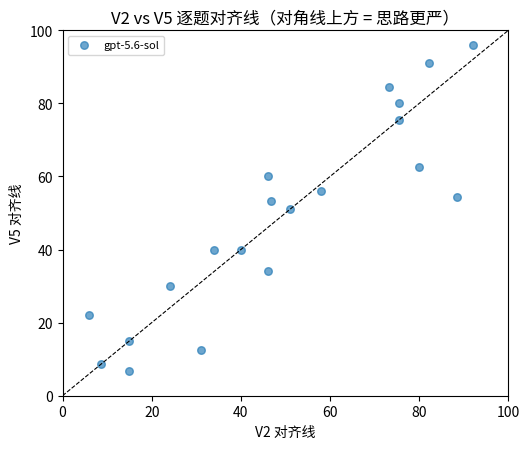

In [44]:
# ---- 消融② 条件 V2 vs V5（判官 = COND_JUDGE，唯一有 V5 配对；其余判官自动剔除）----
df_c = df if COND_JUDGE is None else df[df['judge_model'] == COND_JUDGE]
items_c = items if COND_JUDGE is None else items[items['judge'] == COND_JUDGE]
print(f'判官 = {(COND_JUDGE or "有配对全用").split("/")[-1]}')

# ① 线级差分
lv = df_c.pivot_table(index=['qid', 'judge_model', 'image_model'], columns='schema',
                      values='alignment_score').dropna()
if {'v6.0-V2', 'v6.0-V5'} <= set(lv.columns):
    lv['V5-V2'] = lv['v6.0-V5'] - lv['v6.0-V2']
    print('V5−V2 对齐线差分（正 = 出题思路让判官更严；逐题配对差）：')
    display(lv.groupby(['judge_model', 'image_model'])['V5-V2']
              .agg(['mean', 'median', 'std', 'size']).round(1))

# ② 逐项对比
pivc = items_c.pivot_table(index=['qid', 'judge', 'image_model', 'dim', 'item'],
                           columns='schema', values='score').dropna()
if {'v6.0-V2', 'v6.0-V5'} <= set(pivc.columns):
    it_idx = pivc.index.get_level_values('item')
    pivc['d'] = pivc['v6.0-V5'] - pivc['v6.0-V2']
    g = pivc.groupby(it_idx)
    item_v = pd.DataFrame({'V2均档': g['v6.0-V2'].mean(), 'V5均档': g['v6.0-V5'].mean(),
                           'Δ(V5−V2)': g['d'].mean(),
                           'V5更严': g['d'].apply(lambda s: int((s < 0).sum())),
                           'V5更松': g['d'].apply(lambda s: int((s > 0).sum())),
                           'n': g.size()})
    print('\nV2 vs V5 逐项对比（Δ<0 = 出题思路使该项判得更严）：')
    item_v.index = item_v.index.map(lambda k: ITEM_ZH.get(k, k))
    display(item_v.round(2).sort_values('Δ(V5−V2)'))

    # ③ 逐项明细（分布与迁移方向）
    V_ITEM_SOURCE = None   # None = 两图源合并；或 'gpt-image-2' / 'bagel'
    mig = (pivc.reset_index() if V_ITEM_SOURCE is None
           else pivc.reset_index()[lambda x: x['image_model'] == V_ITEM_SOURCE])
    dd = mig.groupby(['dim', 'item']).apply(lambda x: pd.Series({
        'V2档(0/1/2)': f"{(x['v6.0-V2'] == 0).sum()}/{(x['v6.0-V2'] == 1).sum()}/{(x['v6.0-V2'] == 2).sum()}",
        'V5档(0/1/2)': f"{(x['v6.0-V5'] == 0).sum()}/{(x['v6.0-V5'] == 1).sum()}/{(x['v6.0-V5'] == 2).sum()}",
        'Δ均档': round((x['v6.0-V5'] - x['v6.0-V2']).mean(), 2),
        '严↓': int((x['v6.0-V5'] < x['v6.0-V2']).sum()),
        '松↑': int((x['v6.0-V5'] > x['v6.0-V2']).sum()),
        'n': len(x)}))
    print(f'\n逐项明细（V_ITEM_SOURCE={V_ITEM_SOURCE or "合并"}）：')
    dd.index = dd.index.map(_zh)
    display(dd.sort_values('Δ均档'))

    # ④ 翻转证据下钻
    flips = []
    for r2 in [r for r in rows if r['schema'] == 'v6.0-V2'
               and (COND_JUDGE in (None, r['judge_model']))]:
        r5 = next((x for x in rows if x['qid'] == r2['qid']
                   and x['image_model'] == r2['image_model']
                   and x['judge_model'] == r2['judge_model']
                   and x['schema'] == 'v6.0-V5'), None)
        if not r5:
            continue
        for d, (sk, rk) in RK.items():
            for k, v2 in r2[sk].items():
                v5 = r5[sk][k]
                if v2 != v5 and v2 in (0, 1, 2) and v5 in (0, 1, 2):
                    flips.append({'qid': r2['qid'], '图源': r2['image_model'],
                                  'judge': r2['judge_model'], 'item': k, 'V2': v2, 'V5': v5,
                                  'dim': d, '中文': ITEM_ZH.get(k, k),
                                  'V2证据': str(r2[rk].get(k, ''))[:70],
                                  'V5证据': str(r5[rk].get(k, ''))[:70]})
    flips_df = pd.DataFrame(flips)
    print(f'\nV2/V5 翻转共 {len(flips_df)} 处（V5 严 {int((flips_df.V5 < flips_df.V2).sum())} / '
          f'松 {int((flips_df.V5 > flips_df.V2).sum())}）：')
    if len(flips_df):
        display(flips_df[['qid', '图源', '中文', 'V2', 'V5', 'V2证据', 'V5证据']]
                .sort_values(['qid', '中文']).reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(5.4, 4.6))
    for j, g_ in lv.groupby('judge_model'):
        ax.scatter(g_['v6.0-V2'], g_['v6.0-V5'], alpha=0.65, s=30, label=j.split('/')[-1])
    ax.plot([0, 100], [0, 100], 'k--', lw=0.8)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_xlabel('V2 对齐线'); ax.set_ylabel('V5 对齐线')
    ax.set_title('V2 vs V5 逐题对齐线（对角线上方 = 思路更严）')
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    def show_flip(qid, item=None):
        """打印指定题的全部翻转块：V2/V5 证据全文 + 出题思路 [结论]/[不得画] 终端"""
        q = QS.get(qid, {})
        terms = [ln.strip() for ln in str(q.get('reasoning', '')).split('\n')
                 if '[结论]' in ln or '[不得画]' in ln]
        sub = flips_df[flips_df.qid == qid] if item is None \
            else flips_df[(flips_df.qid == qid) & (flips_df.item == item)]
        for _, f in sub.iterrows():
            print(f"--- [{qid}] {f['图源']} | {f['中文']} | V2={f['V2']} → V5={f['V5']}")
            for schema in ('v6.0-V2', 'v6.0-V5'):
                for r in rows:
                    if (r['qid'] == qid and r['image_model'] == f['图源']
                            and r['schema'] == schema and r['judge_model'] == f['judge']):
                        print(f"  {schema[-2:]}: {str(r[RK[f['dim']][1]].get(f['item'], ''))}")
        for t in terms:
            print(f"  ◇ {t}")

    # show_flip('60002')  /  show_flip('60002', item='spatial_relation')
else:
    print('无 V2/V5 配对数据')

聚焦样本 72 行（judge=全部, cond=全部）
① 图源总览：


,n,align,quality,aesthetic
image_model,,,,
bagel,34,32.0,48.7,61.6
gpt-image-2,38,68.6,68.1,71.4


② 明细项得分（φ 均值 0-100）：


image_model  bagel  gpt-image-2  Δ(B-A)
dim item                               
美感  色彩和谐      63.5         68.4     4.9
    构图        59.4         77.9    18.5
    情绪传达      60.0         60.0     0.0
    光影氛围      63.5         70.5     7.0
对齐  动作交互      17.6         66.8    49.2
    颜色材质      31.0         69.7    38.7
    形态结构      26.5         60.0    33.5
    数量尺度      52.9         75.8    22.9
    场景环境      40.0         64.4    24.4
    空间关系      28.8         56.8    28.0
    状态情境      25.3         68.9    43.6
    风格        46.7         72.0    25.3
    主体在场      31.8         71.6    39.8
    文字符号      35.2         82.1    46.9
质量  解剖保真      60.0         63.1     3.1
    伪影        58.2         60.0     1.8
    细节丰富      38.8         82.1    43.3
    边缘清晰      54.7         68.4    13.7
    材质质感      50.3         82.4    32.1
    自然度       42.4         65.3    22.9
    物理逻辑      50.3         60.0     9.7
    分辨率       45.9         63.2    17.3

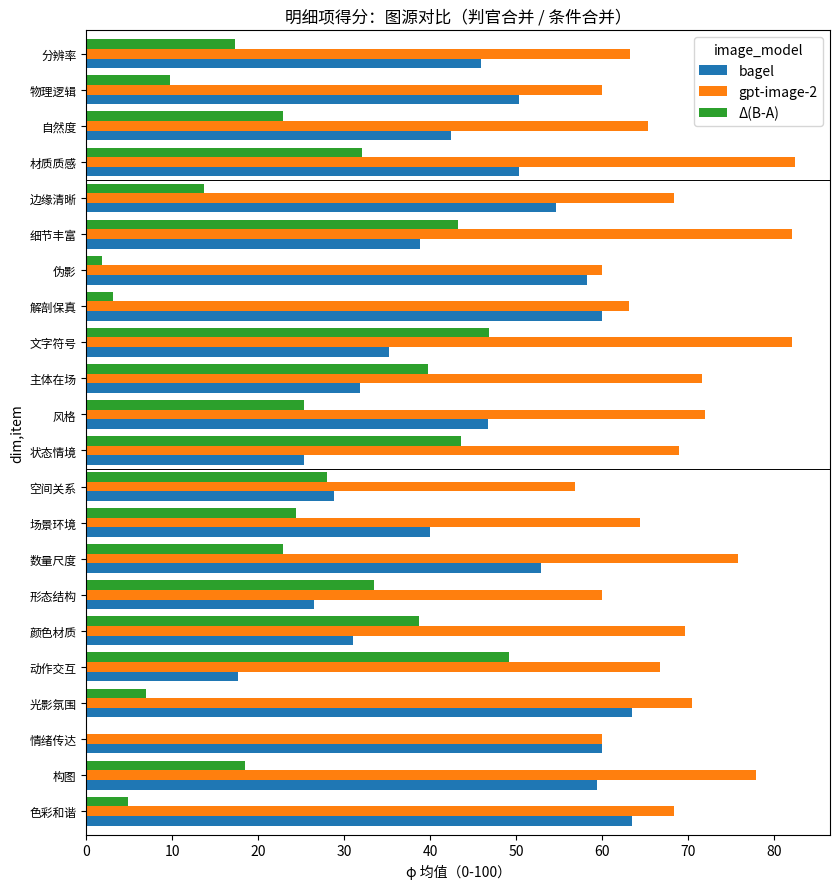

③ 零档频次（最常翻车的项）：


零档次数
image_model 中文        
bagel       动作交互    24
            状态情境    21
            形态结构    19
            空间关系    19
            主体在场    16
            文字符号    15
            颜色材质    15
            细节丰富    12
gpt-image-2 空间关系    12
bagel       自然度     10
            场景环境    10
            数量尺度     8
            分辨率      8
gpt-image-2 形态结构     8
bagel       物理逻辑     5

④ 难度剖面（三线分 × 题目层级）：


n  align  quality  aesthetic
image_model level                               
bagel       L1      3   45.2     48.6       60.0
            L2     13   28.3     50.9       64.6
            L3     18   32.4     47.2       59.6
gpt-image-2 L1      4   78.2     70.0       76.7
            L2     15   70.5     67.9       71.3
            L3     19   65.1     67.8       70.4

⑤ 逐题热力表（对齐十轴；gpt-5.6-sol / v6.0-V5）：


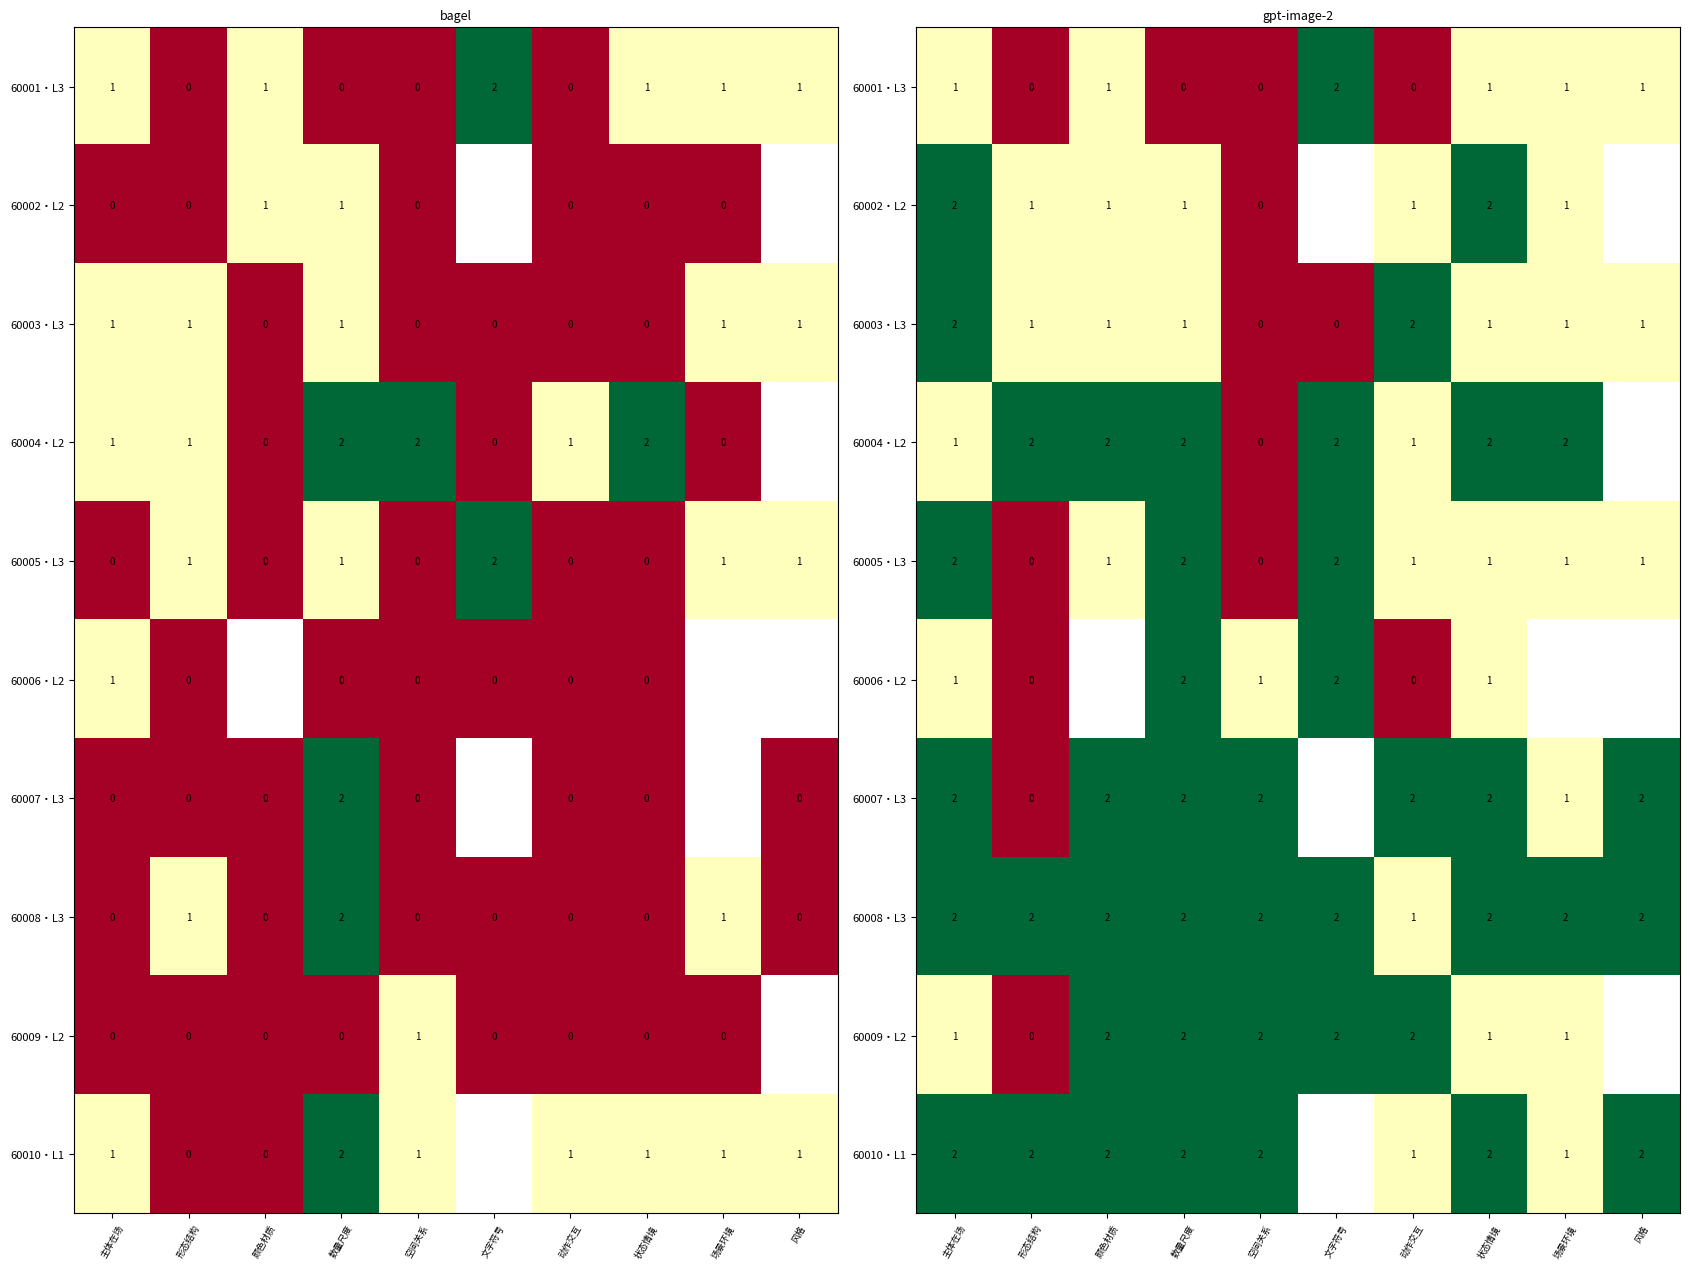

In [ ]:
# ---- 消融③ 图源 bagel vs gpt-image-2 ----
import numpy as np

JUDGE_FOCUS = None   # None = 全判官合并；或 'openrouter/openai/gpt-5.6-sol' 等
COND_FOCUS = None    # None = 两条件合并；或 'v6.0-V5'

d2 = df if JUDGE_FOCUS is None else df[df['judge_model'] == JUDGE_FOCUS]
d2 = d2 if COND_FOCUS is None else d2[d2['schema'] == COND_FOCUS]
sel = [r for r in rows if (JUDGE_FOCUS in (None, r['judge_model']))
       and (COND_FOCUS in (None, r['schema']))]
print(f'聚焦样本 {len(d2)} 行（judge={JUDGE_FOCUS or "全部"}, cond={COND_FOCUS or "全部"}）')

print('① 图源总览：')
display(d2.groupby('image_model')
          .agg(n=('qid', 'size'), align=('alignment_score', 'mean'),
               quality=('quality_score', 'mean'), aesthetic=('aesthetic_score', 'mean'))
          .round(1))

it = pd.DataFrame([
    {'qid': r['qid'], 'image_model': r['image_model'], 'dim': d, 'item': k, 'phi': PHI[v]}
    for r in sel for d, (sk, _) in RK.items()
    for k, v in r[sk].items() if v in (0, 1, 2)])
detail = it.pivot_table(index=['dim', 'item'], columns='image_model', values='phi').round(1)
if len(detail.columns) == 2:
    detail['Δ(B-A)'] = (detail.iloc[:, 1] - detail.iloc[:, 0]).round(1)
detail_zh = detail.copy()
detail_zh.index = detail_zh.index.map(_zh)
print('② 明细项得分（φ 均值 0-100）：')
display(detail_zh)

ax = detail.plot(kind='barh', figsize=(8.5, 9), width=0.8)
ax.set_yticklabels([ITEM_ZH.get(k, k) for _, k in detail.index], fontsize=8.5)
ax.set_xlabel('φ 均值（0-100）')
ax.set_title('明细项得分：图源对比（{} / {}）'.format(
    (JUDGE_FOCUS or '判官合并').split('/')[-1], COND_FOCUS or '条件合并'))
dims = detail.index.get_level_values(0)
n_a = (dims == 'alignment').sum()
ax.axhline(n_a - 0.5, color='k', lw=0.7)
ax.axhline(n_a + (dims == 'quality').sum() - 0.5, color='k', lw=0.7)
plt.tight_layout(); plt.show()

z = (it[it['phi'] == 0].groupby(['image_model', 'item']).size()
      .rename('零档次数').reset_index())
z['中文'] = z['item'].map(lambda k: ITEM_ZH.get(k, k))
print('③ 零档频次（最常翻车的项）：')
display(z.sort_values('零档次数', ascending=False).head(15)
          .set_index(['image_model', '中文'])[['零档次数']])

print('④ 难度剖面（三线分 × 题目层级）：')
display(d2.groupby(['image_model', 'level'])
          .agg(n=('qid', 'size'), align=('alignment_score', 'mean'),
               quality=('quality_score', 'mean'), aesthetic=('aesthetic_score', 'mean'))
          .round(1))

AXES = ['subject_presence', 'form_structure', 'color_material', 'quantity_scale',
        'spatial_relation', 'text_symbol', 'action_interaction', 'state_context',
        'scene_environment', 'style']
HEAT_C = COND_FOCUS or 'v6.0-V5'
_cands = [JUDGE_FOCUS] if JUDGE_FOCUS else sorted({r['judge_model'] for r in rows})
HEAT_J = next((j for j in _cands
               if any(r['judge_model'] == j and r['schema'] == HEAT_C for r in rows)),
              _cands[0])
sub = sorted([r for r in sel if r['judge_model'] == HEAT_J and r['schema'] == HEAT_C],
             key=lambda r: r['qid'])
srcs = sorted({r['image_model'] for r in sub})
if sub:
    print(f'⑤ 逐题热力表（对齐十轴；{HEAT_J.split("/")[-1]} / {HEAT_C}）：')
    fig, axs = plt.subplots(1, len(srcs), squeeze=False,
                            figsize=(1.7 * len(AXES), 0.55 * len(sub) + 1.8))
    for ax, src in zip(axs[0], srcs):
        rs = [r for r in sub if r['image_model'] == src]
        mat = np.array([[np.nan if r['alignment_scores'][a] == 'N/A'
                         else r['alignment_scores'][a] for a in AXES] for r in rs])
        ax.imshow(mat, vmin=0, vmax=2, cmap='RdYlGn', aspect='auto')
        ax.set_xticks(range(len(AXES)))
        ax.set_xticklabels([ITEM_ZH[a] for a in AXES], rotation=60, fontsize=6.5)
        ax.set_yticks(range(len(rs)))
        ax.set_yticklabels([f"{r['qid']}·{r.get('level')}" for r in rs], fontsize=8)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                if not np.isnan(mat[i, j]):
                    ax.text(j, i, int(mat[i, j]), ha='center', va='center', fontsize=7)
        ax.set_title(f"{src}", fontsize=9)
    plt.tight_layout(); plt.show()

def show_reasons(qid, judge=None, cond=None, image_model=None):
    for r in rows:
        if r['qid'] != qid:
            continue
        if judge and r['judge_model'] != judge:
            continue
        if cond and r['schema'] != cond:
            continue
        if image_model and r['image_model'] != image_model:
            continue
        print(f"== {r['qid']} {r['schema']} | {r['judge_model']} | {r['image_model']} "
              f"| align={r['alignment_score']} qual={r['quality_score']} aes={r['aesthetic_score']}")
        for _, rk in RK.values():
            for k, v in r[rk].items():
                print(f"  [{ITEM_ZH.get(k, k)}] {v}")

# show_reasons('60002', image_model='bagel')

[60002] level=L2  题面：植物学观察室内，一株完整带根土团的成熟可育鳞毛蕨正处在刚开始释放孢子的阶段。一片叶被轻柔固定成背面朝上，相邻的一片同龄可育叶保持正面朝上；一张哑光黑色孢子收集卡水平放在翻转叶片的正下方，并已在静止空气中收集一夜。采用略高的近距离斜视角，让两种叶面和下方收集卡同时完整可见。
出题思路（V5 注入）：成熟可育（前提）+ 刚开始释放孢子（前提）+ 鳞毛蕨叶片背面暴露（前提）+ 相邻同龄可育叶正面暴露（前提）+ 黑色收集卡位于翻转叶片正下方（组合）+ 静止空气中收集一夜（前提）
鳞毛蕨的生殖结构为叶背孢子囊群（知识）→ 孢子囊群位于末级羽片的背面（知识）→ 单个囊群呈分离的近圆形斑点（知识）→ [结论] 翻转叶片的末级羽片背面可见许多彼此分离的近圆形孢子囊群
鳞毛蕨叶背孢子囊群（知识）→ 孢子囊群沿末级羽片的叶脉着生（知识）→ 同一羽片两侧叶脉分布近似对称（知识）→ [结论] 近圆形孢子囊群在末级羽片中脉两侧排列成行
鳞毛蕨属的孢子囊群具有肾形囊群盖（知识）→ 开始释放孢子时孢子囊已经成熟（知识）→ 成熟释放阶段囊群盖部分掀起而暴露孢子囊（知识）→ [结论] 清楚可辨的孢子囊群上可见部分掀起的肾形薄膜状囊群盖
孢子囊群着生于叶片背面（知识）→ 叶片正面不是孢子囊群的着生面（知识）→ 相邻同龄可育叶正面朝向镜头（前提）→ [结论] 相邻叶片的正面保持叶面纹理，不出现与背面成行对应的圆形孢子囊群
刚开始释放孢子（前提）→ 成熟孢子囊发生开裂（知识）→ 大量微小孢子从叶背释放（知识）→ 静止空气中孢子主要向下沉降（知识）→ 正下方黑色卡片承接沉降孢子（组合）→ [结论] 黑色收集卡上出现由细粉状孢子形成的清晰沉积
叶背各孢子囊群是孢子的分散释放源（知识）+ 静止空气（前提）→ 孢子沉积位置保留释放源的粗略空间分布（知识）→ 收集卡与翻转叶片上下对应（组合）→ [结论] 卡片上的孢子沉积集中在各产孢羽片正下方，整体呈与羽状叶片相呼应的分枝状孢子印
孢子囊群在中脉两侧成行（知识）+ 孢子向下沉降并被卡片承接（知识）→ 叶背孢子囊群密集处产生更多沉积（知识）→ [结论] 卡片孢子印中较浓的沉积带与上方叶背成行的孢子囊群位置相对应
鳞毛蕨的孢子囊群为叶背分离的近圆形囊群（知识）→ [不得画] 目标鳞毛蕨的孢子囊群不得画成沿叶缘连续延伸的线状带（混

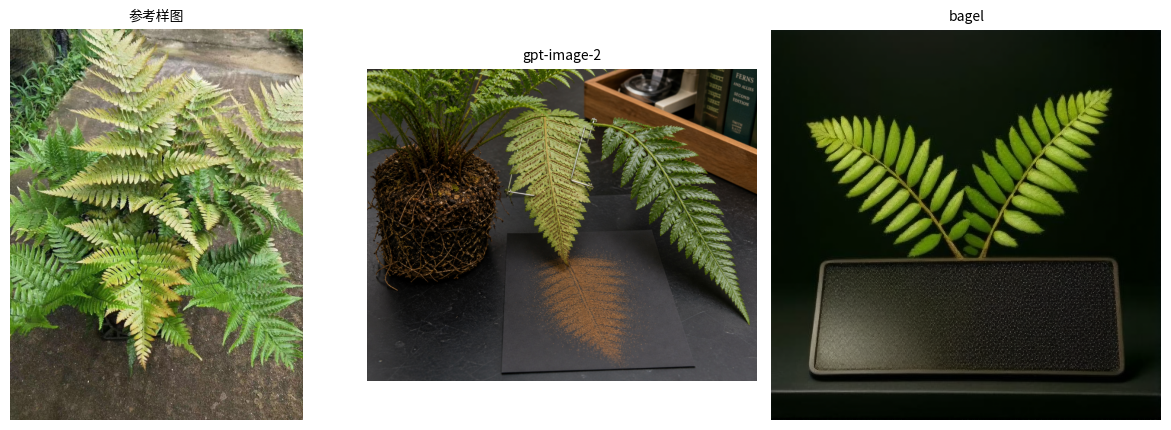

bagel·V2 gpt-image-2·V2 bagel·V5 gpt-image-2·V5
对齐 主体在场        0              1        0              2
   动作交互        0              2        0              1
   场景环境        0              1        0              1
   形态结构        0              2        0              1
   数量尺度        1              1        1              1
   文字符号      N/A            N/A      N/A            N/A
   状态情境        0              1        0              2
   空间关系        0              2        0              0
   颜色材质        1              2        1              1
   风格        N/A            N/A      N/A            N/A
美感 光影氛围        1              1        1              1
   情绪传达      N/A            N/A      N/A            N/A
   构图          1              2        1              2
   色彩和谐        1              2        1              1
质量 伪影          1              1        1              1
   分辨率         1              2        1              1
   材质质感        1              2        1              2
   物理逻辑        1              1        1              1
   细节丰富        0              2        0              2
   自然度         1              1        0              1
   解剖保真      N/A            N/A      N/A            N/A
   边缘清晰        1              2        1              1

[60006] level=L2  题面：绘制一张单页、竖向阅读的梭织衬衫生产流程图，范围从面料到货开始，到成品入库或退回供应商结束。流程须覆盖裁剪、缝制、整烫和包装，只设置面料检验与成衣检验两个质量判断：面料不合格按退供处理；成衣检验若发现缝制缺陷则返修，合格品继续完成后续生产。采用常用标准流程图符号和简短中文节点名，完整表达每个判断的两种结果。
出题思路（V5 注入）：梭织衬衫生产流程（前提）+ 面料到货至入库或退供的流程边界（前提）+ 裁剪、缝制、整烫、包装必须覆盖（前提）
常用标准流程图符号（前提）+ 只设置面料检验与成衣检验两个质量判断（前提）→ 检验结果会改变后续流向（知识）→ 条件性流向需要分支节点（知识）→ 标准流程图用菱形表示判断节点（知识）→ [结论] 图中恰好有两个菱形判断节点
两个质量判断均须完整表达两种结果（前提）→ 每个判断具有二元结果（知识）→ 二元结果分别控制两条后续路径（知识）→ 分支路径用从判断节点发出的流向线表示（知识）→ [结论] 每个菱形判断节点恰有两条向外流出的箭头
面料到货（前提）+ 面料检验（前提）+ 衬衫生产需覆盖裁剪与缝制（前提）→ 原料投入加工前先确认可用性（知识）→ 合格面料才能进入部件加工（知识）→ 衬衫部件需先裁片再缝合（知识）→ [结论] 正常生产主干中，面料检验的合格路径先连接裁剪，再连接缝制
面料不合格按退供处理（前提）→ 不合格原料不得投入裁剪（知识）→ 该分支脱离正常生产主干（知识）→ 退供成为该批面料的结束结果（知识）→ [结论] 面料检验的不合格路径连接到“退回供应商”结束节点
缝制完成（知识）→ 成衣形成后才能检查缝制质量（知识）→ 通过成衣检验后方可进入后整理（知识）→ 后整理先整烫再包装（知识）→ [结论] 正常主干中，缝制之后依次连接成衣检验、整烫和包装
包装完成（知识）+ 成品入库为正常流程终点（前提）→ 包装使产品具备储运状态（知识）→ 完成包装的合格品进入成品库存（知识）→ [结论] 包装节点的主干箭头连接到“成品入库”结束节点
成衣检验发现缝制缺陷则返修（前提）→ 返修应定位到产生该类缺陷的工序（知识）→ 缝制缺陷回到缝制作业修正（知识）→ 修正后的产品必须再次接受成衣检验（知识）→ [结论] 成衣检验的不合格路径回连缝制，并由缝制再次流向成衣检验，形成闭合返修回路
标准流程图

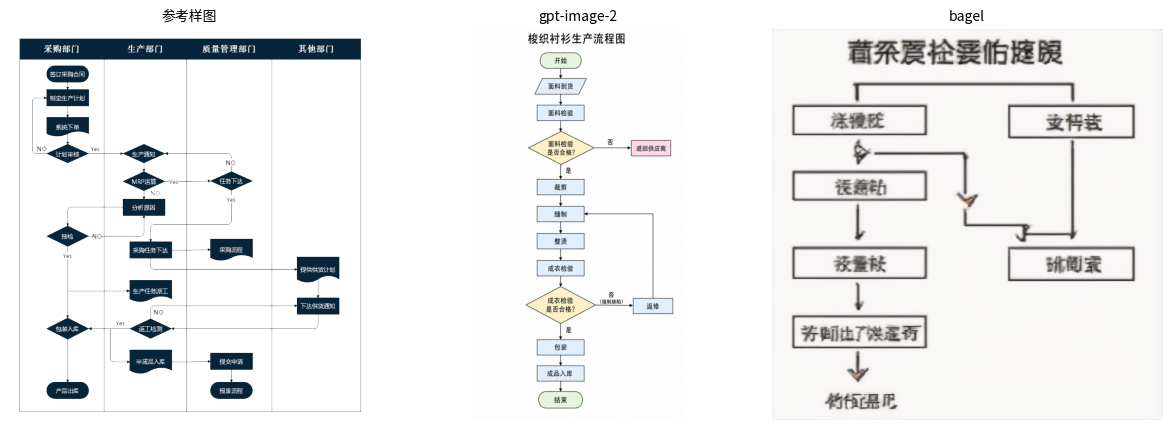

bagel·V2 gpt-image-2·V2 bagel·V5 gpt-image-2·V5
对齐 主体在场        1              1        1              1
   动作交互        0              2        0              0
   场景环境      N/A            N/A      N/A            N/A
   形态结构        0              2        0              0
   数量尺度        0              2        0              2
   文字符号        0              2        0              2
   状态情境        0              1        0              1
   空间关系        0              2        0              1
   颜色材质      N/A            N/A      N/A            N/A
   风格        N/A            N/A      N/A            N/A
美感 光影氛围        1              1        1              1
   情绪传达      N/A            N/A      N/A            N/A
   构图          0              1        0              1
   色彩和谐        1              1        1              1
质量 伪影          1              1        1              1
   分辨率         0              1        0              1
   材质质感      N/A            N/A      N/A            N/A
   物理逻辑      N/A            N/A      N/A            N/A
   细节丰富        0              1        0              1
   自然度         1              1        1              1
   解剖保真      N/A            N/A      N/A            N/A
   边缘清晰        0              1        1              1

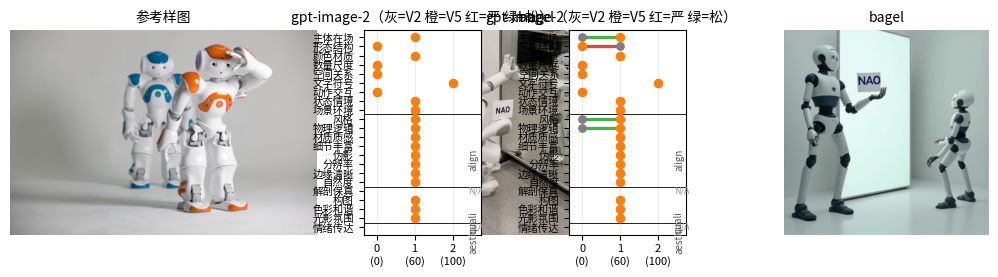

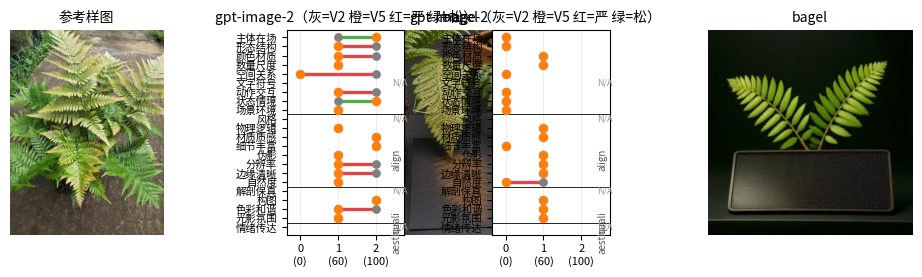

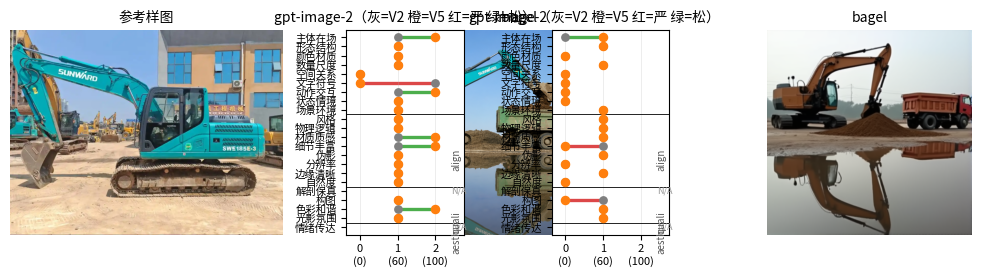

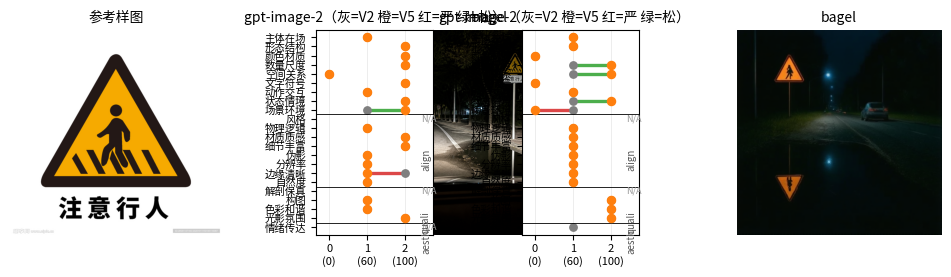

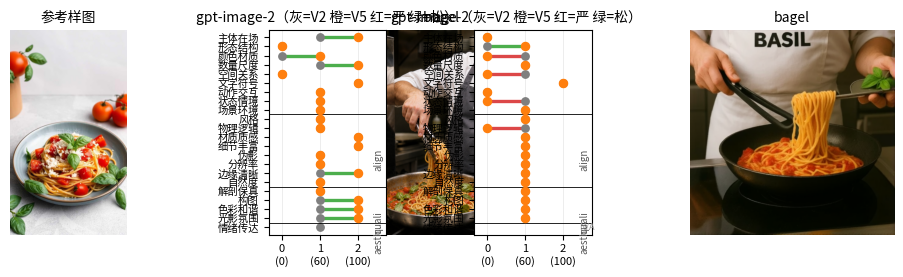

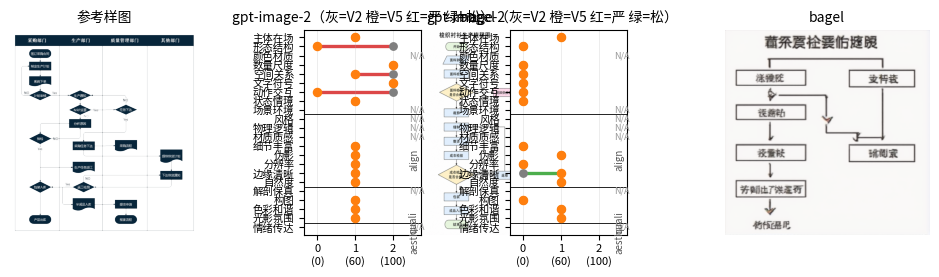

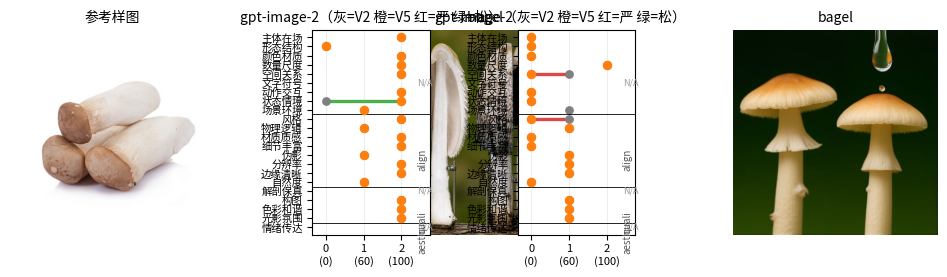

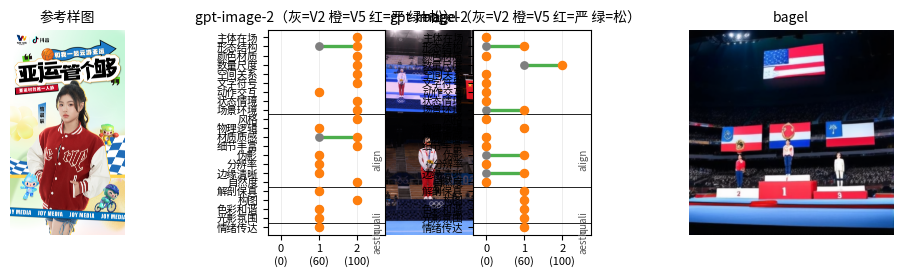

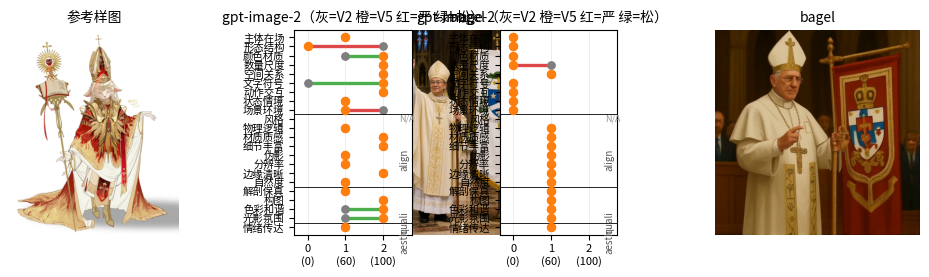

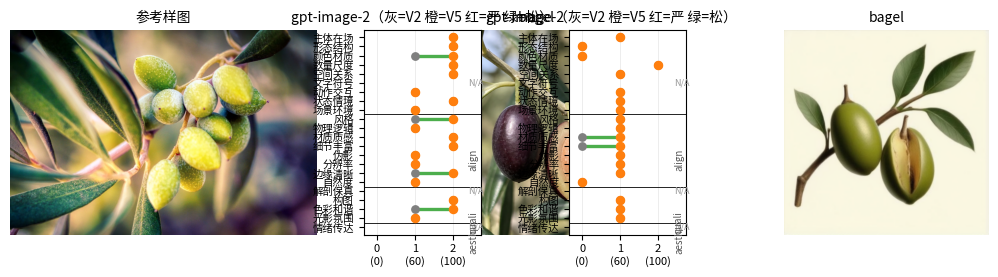

In [ ]:
# ---- case 逐项对比：题面 + 图 + 全组合打分矩阵 + V2/V5 哑铃卡 ----
import numpy as np
from PIL import Image

SHOW = ['all']   # qid 列表；'all' = 全部
CASE_JUDGE = 'openrouter/openai/gpt-5.6-sol'   # 打分矩阵锁 sol；None = 全部判官
SHOW_VV = ['all']            # 哑铃卡 qid；'all' = 全部

AXES = ['subject_presence', 'form_structure', 'color_material', 'quantity_scale',
        'spatial_relation', 'text_symbol', 'action_interaction', 'state_context',
        'scene_environment', 'style']
QUAL = ['physical_logic', 'material_texture', 'detail_richness', 'artifacts',
        'resolution', 'edge_clarity', 'naturalness', 'anatomical_fidelity']
AES = ['composition', 'color_harmony', 'lighting_atmosphere', 'emotional_expression']
ITEMS_VV = [(d, k) for d, keys in (('alignment', AXES), ('quality', QUAL), ('aesthetics', AES))
            for k in keys]


def case_matrix(qid):
    case = [r for r in rows if r['qid'] == qid
            and (CASE_JUDGE in (None, r['judge_model']))]
    n_judge = len({r['judge_model'] for r in case})
    rec = {}
    for r in case:
        col = (f"{r['image_model']}·{r['schema'][-2:]}"
               + (f"·{r['judge_model'].split('/')[-1]}" if n_judge > 1 else ''))
        for d, (sk, _) in RK.items():
            for k, v in r[sk].items():
                rec.setdefault((d, k), {})[col] = v
    mat = pd.DataFrame.from_dict(rec, orient='index')
    mat.index = mat.index.map(_zh)
    return mat.sort_index()


def _dumbbell(ax, r2, r5, title):
    ys = np.arange(len(ITEMS_VV))[::-1]
    for (d, k), yy in zip(ITEMS_VV, ys):
        v2, v5 = r2[RK[d][0]][k], r5[RK[d][0]][k]
        if v2 == 'N/A' and v5 == 'N/A':
            ax.text(2.42, yy, 'N/A', fontsize=6.5, va='center', color='#999999')
            continue
        if v2 != 'N/A' and v5 != 'N/A':
            color = '#d62728' if v5 < v2 else ('#2ca02c' if v5 > v2 else '#bbbbbb')
            ax.plot([v2, v5], [yy, yy], color=color, lw=2.4, alpha=0.85, zorder=1,
                    solid_capstyle='round')
        if v2 != 'N/A':
            ax.scatter([v2], [yy], s=28, color='#7f7f7f', zorder=2)
        if v5 != 'N/A':
            ax.scatter([v5], [yy], s=34, color='#ff7f0e', zorder=3)
    ax.set_yticks(ys)
    ax.set_yticklabels([ITEM_ZH.get(k, k) for _, k in ITEMS_VV], fontsize=7.5)
    bounds = [len([1 for dd, _ in ITEMS_VV if dd == d]) for d in ('alignment', 'quality', 'aesthetics')]
    cum = len(ys)
    for (d, _), b in zip((('alignment', 0), ('quality', 0), ('aesthetics', 0)), bounds):
        cum -= b
        ax.axhline(cum + 0.5, color='k', lw=0.6)
        ax.text(2.42, cum - b / 2 + 0.5, d[:5], fontsize=7, rotation=90,
                va='center', color='#555555')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['0\n(0)', '1\n(60)', '2\n(100)'], fontsize=8)
    ax.set_xlim(-0.35, 2.75)
    ax.set_ylim(-0.8, len(ys) - 0.2)
    ax.set_title(title, fontsize=10)
    ax.grid(axis='x', lw=0.4, alpha=0.4)


# ── A. 全组合打分矩阵（含图）──
for qid in (sorted(df['qid'].unique()) if SHOW == 'all' or 'all' in SHOW else SHOW):
    q = QS.get(qid, {})
    print('=' * 110)
    print(f"[{qid}] level={q.get('level')}  题面：{q.get('gen_prompt', '')}")
    if q.get('reasoning'):
        print(f"出题思路（V5 注入）：{q['reasoning']}")
    panels = [('参考样图', EVAL_DIR / q['_sample_image'] if q.get('_sample_image') else None)]
    panels += [(s, IMG_OF[s](qid)) for s in IMG_OF]
    fig, axs = plt.subplots(1, len(panels), figsize=(4.1 * len(panels), 4.4))
    for ax, (name, p) in zip(np.atleast_1d(axs), panels):
        if p and Path(p).exists():
            ax.imshow(Image.open(p))
        else:
            ax.text(0.5, 0.5, f'缺失\n{p}', ha='center', va='center', fontsize=8)
        ax.set_title(name, fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()
    display(case_matrix(qid))

# ── B. V2/V5 哑铃对照卡 ──
VV_JUDGE = 'openrouter/openai/gpt-5.6-sol'
for qid in (sorted({r['qid'] for r in rows}) if SHOW_VV == 'all' or 'all' in SHOW_VV else SHOW_VV):
    fig = plt.figure(figsize=(13.5, 11))
    gs = fig.add_gridspec(2, 3, height_ratios=[3.0, 8.2], hspace=0.22, wspace=0.12)
    panels = [('参考样图', EVAL_DIR / QS.get(qid, {}).get('_sample_image', '') if QS.get(qid, {}).get('_sample_image') else None)]
    panels += [(s, IMG_OF[s](qid)) for s in IMG_OF]
    for j, (name, p) in enumerate(panels):
        ax = fig.add_subplot(gs[0, j])
        if p and Path(p).exists():
            ax.imshow(Image.open(p))
        else:
            ax.text(0.5, 0.5, '缺失', ha='center', va='center', fontsize=8)
        ax.set_title(name, fontsize=10)
        ax.axis('off')
    sub = gs[1].subgridspec(1, 2, wspace=0.75)
    for j, src in enumerate(('gpt-image-2', 'bagel')):
        ax = fig.add_subplot(sub[0, j])
        r2 = next((r for r in rows if r['qid'] == qid and r['image_model'] == src
                   and r['judge_model'] == VV_JUDGE and r['schema'] == 'v6.0-V2'), None)
        r5 = next((r for r in rows if r['qid'] == qid and r['image_model'] == src
                   and r['judge_model'] == VV_JUDGE and r['schema'] == 'v6.0-V5'), None)
        if not (r2 and r5):
            ax.axis('off')
            ax.set_title(f'{src}: 无 V2/V5 配对', fontsize=9)
            continue
        _dumbbell(ax, r2, r5, f'{src}（灰=V2 橙=V5 红=严 绿=松）')
    plt.show()

In [ ]:
# ---- r10（新梯+弱点乘积批）· 题目明细与历批对照（自包含，可单独运行）----
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

plt.rcParams['font.family'] = ['Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# cwd 自适应：仓库根或 benchmark/t2i/ 启动均可
EVAL_DIR_ = (Path.cwd() / 'data' if (Path.cwd() / 'data' / 'samples_v60_uniform.jsonl').exists()
             else Path.cwd() / 'benchmark' / 't2i' / 'data')
assert EVAL_DIR_.exists(), f'请从仓库根或 benchmark/t2i/ 启动 kernel（当前 {Path.cwd()}）'

R10_DIR = EVAL_DIR_ / 'synth_gen_v60_r10'
R10_EVAL = EVAL_DIR_ / 'eval_v60_r10'
R10_Q = {q['qid']: q for q in
         (json.loads(l) for l in (R10_DIR / 'questions_v60_gpt-5.6-sol.jsonl')
          .read_text(encoding='utf-8').splitlines() if l.strip())}

def _load(fp):
    fp = Path(fp)
    if not fp.exists():
        return {}
    return {r['qid']: r for r in
            (json.loads(l) for l in fp.read_text(encoding='utf-8').splitlines() if l.strip())
            if not r.get('fail')}

S10 = _load(EVAL_DIR_ / 'scores_r10_v60_V2_gpt-5.6-sol_gemini-3.1-flash-image.jsonl')
S9 = _load(EVAL_DIR_ / 'scores_r9_v60_V2_gpt-5.6-sol_gemini-3.1-flash-image.jsonl')
S8 = _load(EVAL_DIR_ / 'scores_r8_v60_V2_gpt-5.6-sol_gemini-3.1-flash-image.jsonl')
S6 = _load(EVAL_DIR_ / 'scores_r6_v60_V2_gpt-5.6-sol_gemini-3.1-flash-image.jsonl')

GATE_PRE = {'L1': 6, 'L2': 8, 'L3': 8}

print('① 结构指标 vs 门槛（六表门槛对照；复合标注按类别段计数）')
rows = []
for qid, q in sorted(R10_Q.items()):
    rs = str(q.get('reasoning') or '')
    kinds = {d.split('；域·')[0] for d in re.findall(r'（知识·([^）]+)）', rs)}
    kdoms = q.get('knowledge_domains') or []
    main_dom = kdoms[0] if kdoms else None
    rows.append({'qid': qid, 'level': q.get('level'),
                 '前提': rs.count('（前提）'), '门槛': GATE_PRE.get(q.get('level')),
                 '结论': rs.count('[结论]'),
                 '前提类': len(set(q.get('premise_types') or [])),
                 '跳类型': len(set(q.get('hop_types') or [])),
                 '跨度类': len(kinds),
                 '跨域': len([d for d in kdoms[1:]]) if main_dom else 0,
                 '弱项': len(set(q.get('weak_points') or [])),
                 'combo': q.get('combo_type'),
                 'r6': (S6.get(qid) or {}).get('alignment_score'),
                 'r8': (S8.get(qid) or {}).get('alignment_score'),
                 'r9': (S9.get(qid) or {}).get('alignment_score'),
                 'r10': (S10.get(qid) or {}).get('alignment_score')})
display(pd.DataFrame(rows).set_index('qid'))

SHOW_R10 = ['all']   # qid 列表或 'all'

for qid in (sorted(R10_Q) if SHOW_R10 == 'all' or 'all' in SHOW_R10 else SHOW_R10):
    q = R10_Q.get(qid, {})
    print('=' * 110)
    print(f"[{qid}] level={q.get('level')}  combo={q.get('combo_type')}  "
          f"weak_points={q.get('weak_points')}")
    print(f"题面：{q.get('gen_prompt', '')}")
    print(f"level_reason：{q.get('level_reason', '')}")
    print(f"reasoning：\n{q.get('reasoning', '')}")
    p = R10_EVAL / 'imgs' / 'gemini-3.1-flash-image' / f'{qid}.png'
    s = S10.get(qid)
    if p.exists():
        fig, ax = plt.subplots(figsize=(4.6, 4.8))
        ax.imshow(Image.open(p))
        ax.set_title(f"gemini·r10\n对齐 {s['alignment_score']} | 质量 {s['quality_score']} | 美感 {s['aesthetic_score']}"
                     if s else '无判分', fontsize=9)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

    # ── 明细打分项：22 项逐项档位（r10 + 历批同题对照）+ 非常档理由 ──
    if s:
        ITEM_ZH = {'subject_presence': '主体在场', 'form_structure': '形态结构',
                   'color_material': '颜色材质', 'quantity_scale': '数量尺度',
                   'spatial_relation': '空间关系', 'text_symbol': '文字符号',
                   'action_interaction': '动作交互', 'state_context': '状态情境',
                   'scene_environment': '场景环境', 'style': '风格',
                   'physical_logic': '物理逻辑', 'material_texture': '材质质感',
                   'detail_richness': '细节丰富', 'artifacts': '伪影', 'resolution': '分辨率',
                   'edge_clarity': '边缘清晰', 'naturalness': '自然度',
                   'anatomical_fidelity': '解剖保真', 'composition': '构图',
                   'color_harmony': '色彩和谐', 'lighting_atmosphere': '光影氛围',
                   'emotional_expression': '情绪传达'}
        DIM_ZH = {'alignment': '对齐', 'quality': '质量', 'aesthetics': '美感'}
        RK10 = {'alignment': ('alignment_scores', 'alignment_reasons'),
                'quality': ('quality_scores', 'quality_reasons'),
                'aesthetics': ('aesthetic_scores', 'aesthetic_reasons')}
        print('── 明细打分项（r10 / gpt-5.6-sol / V2；一行一项：档位＋理由全文）')
        for d, (sk, rk) in RK10.items():
            for k, v in s[sk].items():
                print(f"  [{DIM_ZH[d]}·{ITEM_ZH.get(k, k)}] {v}：{s[rk].get(k, '')}")